In [1]:
import torch
from torch import nn

In [2]:
def angles_to_rmat3d(angles):
    x, y, z = torch.unbind(angles, axis=-1)
    N = len(x)

    A = torch.eye(3, device=x.device).repeat(N, 1, 1)
    B = torch.eye(3, device=x.device).repeat(N, 1, 1)
    C = torch.eye(3, device=x.device).repeat(N, 1, 1)

    cos_z = torch.cos(z)
    sin_z = torch.sin(z)

    A[:, 0, 0] = cos_z
    A[:, 0, 1] = -sin_z
    A[:, 1, 0] = sin_z
    A[:, 1, 1] = cos_z

    cos_y = torch.cos(y)
    sin_y = torch.sin(y)

    B[:, 0, 0] = cos_y
    B[:, 0, 2] = sin_y
    B[:, 2, 0] = -sin_y
    B[:, 2, 2] = cos_y

    cos_x = torch.cos(x)
    sin_x = torch.sin(x)

    C[:, 1, 1] = cos_x
    C[:, 1, 2] = -sin_x
    C[:, 2, 1] = sin_x
    C[:, 2, 2] = cos_x

    return A @ B @ C

In [3]:
class Retina(nn.Module):
    def __init__(
        self, degree=90, height=144, width=256, mlp_features=[12, 12], device=None
    ):
        super().__init__()

        self.grid = self.create_grid(height, width, degree, device=device)

        layers = []
        for d_in, d_out in zip([2] + mlp_features, mlp_features + [3]):
            layers.append(nn.Linear(d_in, d_out))
            layers.append(nn.ReLU())

        self.mlp = nn.Sequential(*layers)

    def create_grid(self, height, width, degree, device):
        # Create isotropic grid of retina
        x_axis = torch.linspace(-1, 1, width, device=device)
        y_axis = torch.linspace(-1, 1, height, device=device) * height / width
        scale = (width - 1) / width

        x, y = torch.meshgrid(
            x_axis * scale,
            y_axis * scale,
            indexing="xy",
        )

        # Convert to grid of 3D rays corresponding to retina pixels
        radians = degree / 180 * torch.pi

        r = torch.sqrt(x.pow(2) + y.pow(2)).mul(radians).clip(0, torch.pi / 2)
        cos_r = torch.cos(r)
        sin_r = torch.sin(r)

        theta = torch.atan2(y, x)
        cos_theta = torch.cos(theta)
        sin_theta = torch.sin(theta)

        ray_grid = [
            sin_r * cos_theta,
            sin_r * sin_theta,
            cos_r,
        ]

        return torch.stack(ray_grid, dim=-1)

    def rotate_retina(self, rmat):
        return torch.einsum("N C D , H W D -> N H W C", rmat, self.grid)

    # Take pupil center to return rotated grid of retina rays
    def rays(self, pupil_center):
        angles = self.mlp(pupil_center)
        rmat = angles_to_rmat3d(angles)
        rays = self.rotate_retina(rmat)

        return rays

In [ ]:
class Monitor(nn.Module):
    def __init__(
        self,
        init_center_x=0,
        init_center_y=0,
        init_center_z=0.5,
        init_center_std=0.05,
        init_angle_x=0,
        init_angle_y=0,
        init_angle_z=0,
        init_angle_std=0.05,
        eps=1e-5,
        device=None,
    ):
        super().__init__()

        self.center = nn.Parameter(
            torch.tensor(
                [
                    init_center_x,
                    init_center_y,
                    init_center_z,
                ],
                dtype=torch.float32,
                device=device,
            )
        )
        self.angle = nn.Parameter(
            torch.tensor(
                [
                    init_angle_x,
                    init_angle_y,
                    init_angle_z,
                ],
                dtype=torch.float32,
                device=device,
            )
        )
        self.center_std = nn.Parameter(
            torch.tensor(init_center_std, dtype=torch.float32, device=device)
        )
        self.angle_std = nn.Parameter(
            torch.tensor(init_angle_std, dtype=torch.float32, device=device)
        )
        self.eps = float(eps)

    # Optimize position of monitor
    def position(self, batch_size):
        center = self.center.repeat(batch_size, 1)
        angle = self.angle.repeat(batch_size, 1)

        if self.training:
            center = (
                center
                + torch.randn(batch_size, 3, device=center.device) * self.center_std
            )
            angle = (
                angle + torch.randn(batch_size, 3, device=angle.device) * self.angle_std
            )

        x, y, z = angles_to_rmat3d(angle).unbind(2)

        return center, x, y, z

    # Project rays onto monitor coordinates
    def project(self, rays):
        center, x, y, z = self.position(len(rays))

        a = torch.einsum("N D , N D -> N", z, center)[:, None, None]
        b = torch.einsum("N D , N H W D -> N H W", z, rays).clip(self.eps)

        c = torch.einsum("N H W , N H W D -> N H W D", a / b, rays)
        d = c - center[:, None, None, :]

        proj = [
            torch.einsum("N H W D , N D -> N H W", d, x),
            torch.einsum("N H W D , N D -> N H W", d, y),
        ]
        return torch.stack(proj, dim=3)

    # Samples values in img at positions given by grid
    def sample_screen(self, img, grid):
        _, _, H_in, W_in = img.shape
        grid_x, grid_y = grid.unbind(dim=3)

        grid_y = grid_y * W_in / H_in
        scale = W_in / (W_in - 1)

        _, H_out, W_out, _ = grid.shape
        grid = [
            grid_x * scale * (W_out - 1) / W_out,
            grid_y * scale * (H_out - 1) / H_out,
        ]

        return nn.functional.grid_sample(
            input=img,
            grid=torch.stack(grid, dim=3),
            mode="bilinear",
            align_corners=False,
        )

In [5]:
# Combines Retina and Monitor


class Perspective(nn.Module):
    def __init__(self, retina, monitor):
        super().__init__()

        self.retina = retina
        self.monitor = monitor

    def forward(self, img, pupil_center):
        rays = self.retina.rays(pupil_center)
        grid = self.monitor.project(rays)
        pixels = self.monitor.sample_screen(img, grid)

        return pixels

In [6]:
import matplotlib.pyplot as plt
from nnfabrik.builder import get_data

device = "cuda:7"
torch.cuda.set_device(device)

filenames = [
    "/srv/user/polina/sensorium/sensorium/notebooks/data/static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip",
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 32,
    "scale": 1,
}

dataloaders = get_data(dataset_fn, dataset_config)

data_key = "27204-5-13"
batch = next(iter(dataloaders["train"][data_key]))

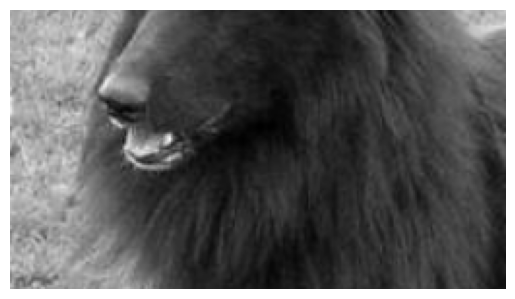

In [7]:
plt.imshow(batch.images[0, 0].to("cpu").numpy(), cmap="gray")
plt.axis("off")
plt.show()

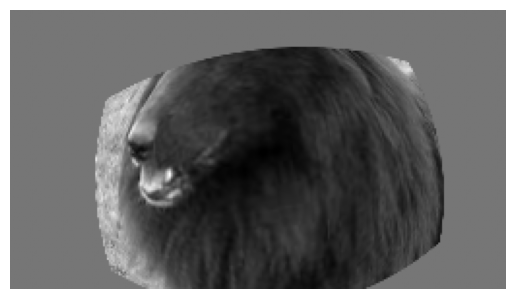

In [8]:
perspective = Perspective(Retina(device=device), Monitor(device=device)).to(device)

out = perspective(batch.images, batch.pupil_center)
img = out[0, 0].detach().to("cpu").numpy()
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [9]:
params = perspective.parameters()
for param in params:
    print(param.shape)

torch.Size([12, 2])
torch.Size([12])
torch.Size([12, 12])
torch.Size([12])
torch.Size([3, 12])
torch.Size([3])
torch.Size([3])
torch.Size([3])
torch.Size([])
torch.Size([])


In [10]:
optimiter = torch.optim.Adam(perspective.parameters(), lr=1e-3)

In [11]:
for iter in range(5):
    print(iter)
    img = torch.randn(32, 1, 144, 256, device=device)
    pupil_center = torch.randn(32, 2, device=device)

    out = perspective(img, pupil_center)

    loss = out.sum()

    loss.backward()
    optimiter.step()
    optimiter.zero_grad()

0
1
2
3
4
